# Modélisation du prix par nuit

**Objectif :** prédire le prix par nuit d'un logement Airbnb à Montréal à partir de ses caractéristiques
et de son emplacement.

**Démarche :**
1. Séparer les données : 80 % pour l'entraînement, 20 % pour le test final.
2. Comparer une référence naïve et trois modèles en **validation croisée à 5 plis** sur l'entraînement.
3. Évaluer le modèle retenu **une seule fois** sur le jeu de test.
4. Comprendre ce que le modèle a appris (importance des variables) et où il se trompe (analyse des erreurs).

Le modèle final est entraîné et sauvegardé par `python -m src.train` : ce notebook le recharge pour l'analyser.

## 1. Préparation des données

Je recharge les annonces nettoyées et enrichies (voir `01_exploration.ipynb`), puis je les sépare en
entraînement et test. La fonction `split()` utilise un `random_state` fixe : j'obtiens exactement la même
séparation que dans `src/train.py`, et le jeu de test n'a donc jamais servi à entraîner le modèle.

In [1]:
import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.inspection import permutation_importance
from sklearn.metrics import mean_absolute_error, r2_score

from src.config import MODEL_PATH, RANDOM_STATE, ROOT
from src.model import NeighbourhoodMedianBaseline, build_models, cross_validate_models
from src.train import load_dataset, split

sns.set_theme(style="whitegrid")
FIGURES = ROOT / "figures"

df = load_dataset()
X_train, X_test, y_train, y_test = split(df)
len(X_train), len(X_test)

(7332, 1833)

- **7 332 annonces** pour l'entraînement et **1 833** pour le test.
- Le jeu de test reste de côté jusqu'à l'évaluation finale : tous les choix (quel modèle, quels
  hyperparamètres) se font uniquement sur l'entraînement. Sinon, le score de test serait trop optimiste.

## 2. Comparaison des modèles

Je compare quatre approches, de la plus simple à la plus complexe :

| Modèle | Idée |
|---|---|
| **Médiane du quartier** | Référence naïve : prédit le prix médian du quartier, sans rien regarder d'autre |
| **Ridge** | Régression linéaire avec régularisation : simple et interprétable |
| **Random Forest** | Moyenne de nombreux arbres de décision : capte les effets non linéaires |
| **Gradient Boosting** | Arbres construits l'un après l'autre, chacun corrigeant les erreurs du précédent |

Chaque modèle est un `Pipeline` scikit-learn qui regroupe le prétraitement (valeurs manquantes remplacées
par la médiane, encodage des catégories) et le modèle. Tous apprennent le **logarithme du prix**, mais
leurs prédictions sont reconverties en dollars.

**Validation croisée à 5 plis :** l'entraînement est coupé en 5 parts ; chaque modèle est entraîné sur 4 parts
et évalué sur la 5ᵉ, cinq fois de suite. La moyenne des 5 scores est plus fiable qu'un seul découpage.

**Métriques :**
- **MAE** (erreur absolue moyenne) : l'écart moyen, en dollars, entre le prix prédit et le vrai prix.
- **R²** : la part des variations de prix expliquée par le modèle (1 = parfait, 0 = pas mieux que la moyenne).

,modèle,MAE ($),R²
0,Random Forest,54.739,0.643
1,Gradient Boosting,55.516,0.641
2,Ridge,67.278,0.483
3,Médiane du quartier,106.552,0.017


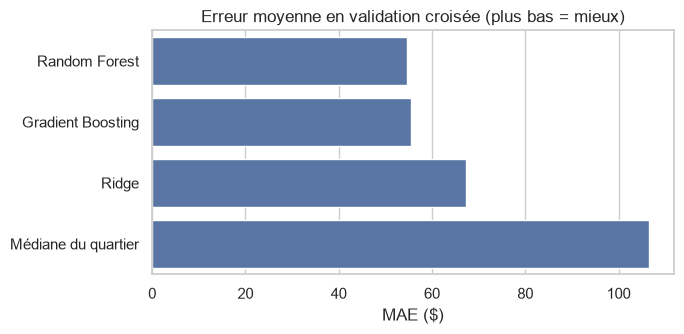

In [2]:
scores = cross_validate_models(build_models(), X_train, y_train)

fig, ax = plt.subplots(figsize=(7, 3.5))
sns.barplot(data=scores, x="MAE ($)", y="modèle", ax=ax)
ax.set(title="Erreur moyenne en validation croisée (plus bas = mieux)", ylabel="")
fig.tight_layout()
fig.savefig(FIGURES / "model_comparison.png", dpi=120)
scores.round(3)

| Modèle | MAE (validation croisée) | R² |
|---|---:|---:|
| Médiane du quartier | 106,6 $ | 0,02 |
| Ridge | 67,3 $ | 0,48 |
| Gradient Boosting | 55,5 $ | 0,64 |
| **Random Forest** | **54,7 $** | **0,64** |

- **La référence naïve est très mauvaise** (R² ≈ 0) : connaître le quartier ne suffit presque pas à prédire le prix.
- **Ridge fait déjà beaucoup mieux**, mais un modèle linéaire ne capte pas les effets « en escalier » ni les
  combinaisons de variables (par exemple : logement entier **et** location à la nuit).
- **Les deux modèles à base d'arbres sont au coude à coude** et divisent l'erreur de la référence par deux.
  Moins de 1 $ les sépare : c'est dans la marge d'incertitude. Je retiens le Random Forest, le meilleur de peu.

`src/train.py` règle ensuite les hyperparamètres du Random Forest avec `RandomizedSearchCV` : il retient
`max_features = 0.5` (chaque découpage d'arbre ne regarde que la moitié des variables) et
`min_samples_leaf = 2`.

## 3. Évaluation finale sur le jeu de test

C'est la première et la seule fois que j'utilise le jeu de test. Il mesure la performance sur des annonces
que le modèle n'a jamais vues, comme dans l'app.

In [3]:
artifact = joblib.load(MODEL_PATH)
model = artifact["model"]
baseline = NeighbourhoodMedianBaseline().fit(X_train, y_train)

pd.DataFrame(
    {
        "modèle": ["Médiane du quartier", artifact["model_name"]],
        "MAE test ($)": [mean_absolute_error(y_test, baseline.predict(X_test)), mean_absolute_error(y_test, model.predict(X_test))],
        "R² test": [r2_score(y_test, baseline.predict(X_test)), r2_score(y_test, model.predict(X_test))],
    }
).round(3)

,modèle,MAE test ($),R² test
0,Médiane du quartier,104.424,-0.003
1,Random Forest,52.239,0.687


| Modèle | MAE test | R² test |
|---|---:|---:|
| Médiane du quartier | 104,4 $ | 0,00 |
| **Random Forest (réglé)** | **52,2 $** | **0,69** |

- **L'erreur moyenne est divisée par deux** par rapport à la référence naïve.
- Le modèle explique environ **69 %** des variations de prix.
- Les scores de test sont proches de ceux de la validation croisée (54,7 $) : le modèle **ne surapprend pas**,
  il généralise bien à de nouvelles annonces.
- En erreur relative, **la moitié des estimations sont à moins de 21 % du vrai prix**, contre 47 % pour la
  référence. C'est cette valeur qui sert à calculer la fourchette affichée dans l'app.

## 4. Quelles variables comptent le plus ?

J'utilise l'**importance par permutation** : je mélange au hasard les valeurs d'une colonne du jeu de test,
ce qui casse son lien avec le prix, et je mesure de combien l'erreur moyenne augmente. Plus elle
augmente, plus le modèle dépend de cette variable.

Cette méthode a deux avantages : elle marche pour n'importe quel modèle, et elle se calcule sur le
jeu de test, donc sur ce que le modèle a vraiment appris à généraliser.

minimum_nights            43.29
accommodates              11.35
bathrooms                  7.26
dist_downtown_km           7.16
bedrooms                   5.09
room_type                  4.83
n_amenities                4.26
longitude                  3.02
latitude                   2.27
dist_metro_km              1.64
bath_shared                1.19
beds                       0.84
has_ac                     0.65
neighbourhood_cleansed     0.48
has_parking                0.18
has_kitchen                0.11
has_wifi                  -0.02
dtype: float64

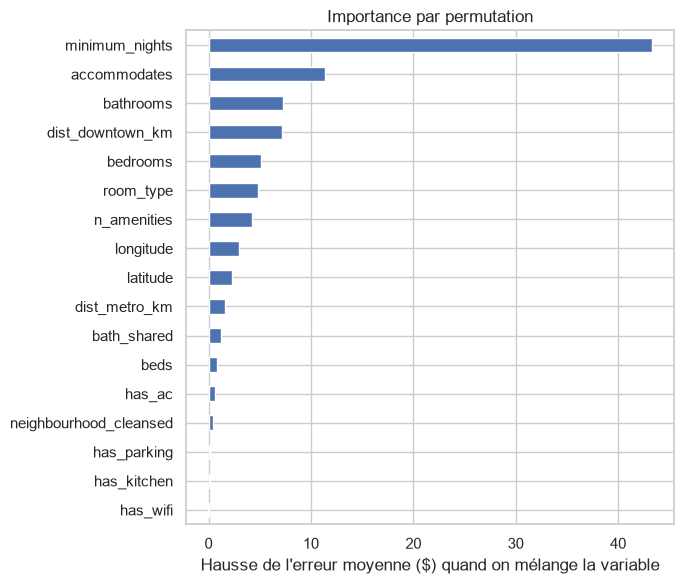

In [4]:
importance = permutation_importance(
    model, X_test, y_test, scoring="neg_mean_absolute_error", n_repeats=5, random_state=RANDOM_STATE, n_jobs=-1
)
importances = pd.Series(importance.importances_mean, index=X_test.columns).sort_values()
fig, ax = plt.subplots(figsize=(7, 6))
importances.plot.barh(ax=ax)
ax.set(title="Importance par permutation", xlabel="Hausse de l'erreur moyenne ($) quand on mélange la variable")
fig.tight_layout()
fig.savefig(FIGURES / "feature_importance.png", dpi=120)
importances.sort_values(ascending=False).round(2)

- **La durée minimale de séjour domine largement** : la mélanger augmente l'erreur de **+43 $**. C'est
  quatre fois plus que la variable suivante. Ça confirme l'exploration : distinguer les locations au mois
  des locations à la nuit est la première chose que le modèle apprend.
- Viennent ensuite **la capacité** (+11 $), **les salles de bain** (+7 $), **la distance au centre-ville** (+7 $),
  les chambres (+5 $) et le type de logement (+5 $).
- **Le quartier ne compte presque pas** (+0,5 $). Ce n'est pas que l'emplacement soit inutile : la latitude,
  la longitude et la distance au centre-ville portent déjà cette information, de façon plus précise.
- **Le Wi-Fi n'apporte rien** (≈ 0 $) : presque tous les logements l'ont, donc il ne permet pas de les distinguer.

## 5. Prix prédit contre prix réel

Chaque point est une annonce du jeu de test. Si le modèle était parfait, tous les points seraient sur la
diagonale rouge. Les deux axes sont en échelle logarithmique, pour bien voir les petits comme les grands prix.

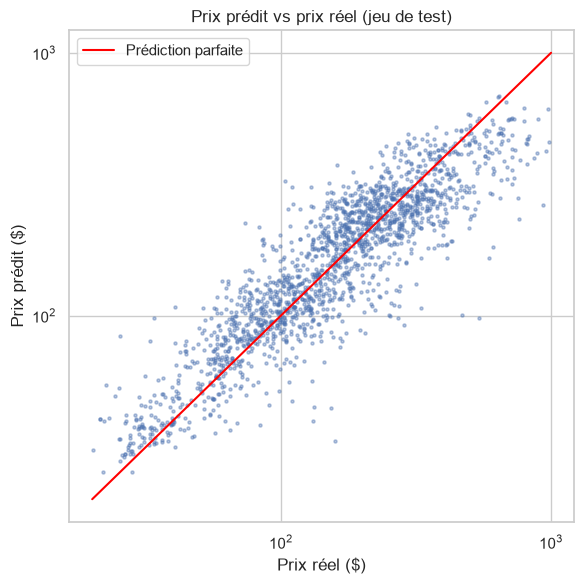

In [5]:
predictions = model.predict(X_test)
fig, ax = plt.subplots(figsize=(6, 6))
ax.scatter(y_test, predictions, s=5, alpha=0.4)
ax.plot([20, 1000], [20, 1000], color="red", label="Prédiction parfaite")
ax.set(xscale="log", yscale="log", xlabel="Prix réel ($)", ylabel="Prix prédit ($)", title="Prix prédit vs prix réel (jeu de test)")
ax.legend()
fig.tight_layout()
fig.savefig(FIGURES / "predicted_vs_actual.png", dpi=120)

- Le nuage suit bien la diagonale : le modèle a capté la tendance générale.
- Mais il est **plus « plat » que la diagonale** : les petits prix sont plutôt surestimés et les grands prix
  sous-estimés. Le modèle a tendance à **tirer ses prédictions vers la moyenne**, un comportement typique
  des Random Forest, qui font des moyennes d'arbres.

## 6. Où le modèle se trompe-t-il ?

Je calcule l'erreur de chaque annonce du jeu de test, puis je la regroupe par quartier, par type de
logement et par gamme de prix. Je ne garde que les quartiers avec au moins 20 annonces de test, pour que les
moyennes aient un sens.

In [6]:
errors = X_test.assign(price=y_test, predicted=predictions, abs_error=np.abs(y_test - predictions))
by_hood = (
    errors.groupby("neighbourhood_cleansed")
    .agg(annonces=("price", "size"), prix_median=("price", "median"), mae=("abs_error", "mean"))
    .query("annonces >= 20")
    .sort_values("mae", ascending=False)
)
by_hood.round(1)

,annonces,prix_median,mae
neighbourhood_cleansed,,,
Le Plateau-Mont-Royal,379,204.3,66.4
Ville-Marie,681,176.3,54.7
Le Sud-Ouest,138,141.2,52.2
Rosemont-La Petite-Patrie,127,116.5,50.5
Mercier-Hochelaga-Maisonneuve,93,121.3,40.5
Ahuntsic-Cartierville,40,94.9,38.8
Côte-des-Neiges-Notre-Dame-de-Grâce,155,88.9,34.6
Verdun,24,77.5,31.6
Villeray-Saint-Michel-Parc-Extension,53,129.8,30.7


In [7]:
print(errors.groupby("room_type")["abs_error"].mean().round(1))
errors["price_bin"] = pd.cut(errors["price"], [20, 100, 200, 400, 1000])
errors.groupby("price_bin", observed=True)["abs_error"].agg(["size", "mean"]).round(1)

room_type
Entire home/apt    57.8
Private room       24.2
Name: abs_error, dtype: float64


,size,mean
price_bin,,
"(20, 100]",537,18.6
"(100, 200]",589,39.7
"(200, 400]",533,59.5
"(400, 1000]",174,176.0


**Par quartier :** l'erreur est la plus forte là où les prix sont les plus élevés, comme **Le Plateau-Mont-Royal
(66 $)** et Ville-Marie (55 $), et la plus faible dans les quartiers moins chers, comme Verdun (32 $) ou
Villeray (31 $). C'est en grande partie mécanique : se tromper de 20 % sur 200 $ fait plus de dollars que sur 80 $.

**Par type de logement :** 58 $ d'erreur moyenne pour les logements entiers, contre 24 $ pour les chambres privées,
qui sont moins chères et plus homogènes.

**Par gamme de prix :**

| Prix réel | Annonces | Erreur moyenne | Prix réel moyen | Prix prédit moyen |
|---|---:|---:|---:|---:|
| 20 $ – 100 $ | 537 | 19 $ | 64 $ | 78 $ |
| 100 $ – 200 $ | 589 | 40 $ | 148 $ | 165 $ |
| 200 $ – 400 $ | 533 | 60 $ | 279 $ | 265 $ |
| 400 $ – 1 000 $ | 174 | **176 $** | 559 $ | **392 $** |

Ce tableau confirme le graphique précédent : **le modèle sous-estime fortement les logements haut de gamme**.
En moyenne, il prédit 392 $ pour des logements qui en valent 559 $. Ces logements sont rares (moins de 10 % du
test), et ce qui les rend chers (vue, design, prestations) n'apparaît pas dans mes variables.

## 7. Conclusion

- **Le Random Forest prédit le prix par nuit avec une erreur moyenne de 52 $** sur des annonces jamais vues
  (R² = 0,69). C'est deux fois mieux que la référence naïve (104 $), et la moitié des estimations sont
  à moins de 21 % du vrai prix.
- **La durée minimale de séjour est de loin la variable la plus importante**, suivie de la taille du logement
  et de sa distance au centre-ville.
- Le modèle est **fiable pour les logements courants** (moins de 400 $), mais **sous-estime nettement le haut de gamme**.

## 8. Limites et pistes d'amélioration

**Limites :**
- **Un seul instantané** (juin 2026) : le modèle ignore la saisonnalité (Grand Prix, festivals, hiver).
- **Le prix affiché n'est pas forcément le prix payé** : il ne tient compte ni des frais de ménage,
  ni des réductions à la semaine ou au mois.
- **Les descriptions et les photos ne sont pas utilisées**, alors qu'elles expliquent sûrement une partie
  des prix élevés.
- **Peu d'exemples de logements haut de gamme** pour apprendre leurs prix.

**Pistes :**
- Entraîner **deux modèles séparés**, un pour la location à la nuit et un pour la location au mois,
  puisque ce sont presque deux marchés différents.
- Utiliser **plusieurs instantanés** sur l'année pour capter la saisonnalité.
- Extraire des informations des **descriptions** (NLP) : « vue », « terrasse », « luxe »…
- Ajouter des **données de quartier** : commerces, parcs, attraits touristiques.